In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
df=pd.read_csv(r"D:\Qspider\ml\Projects\House_price_prediction\dataset\Bengaluru_House_Data (1).csv")
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [4]:
df=df.drop(["area_type","availability","society","balcony"],axis=1)
df.head()

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00


Handling the missing values

In [5]:
df.isnull().sum()

location       1
size          16
total_sqft     0
bath          73
price          0
dtype: int64

In [6]:
df["location"].value_counts()

location
Whitefield                        540
Sarjapur  Road                    399
Electronic City                   302
Kanakpura Road                    273
Thanisandra                       234
                                 ... 
Bapuji Layout                       1
1st Stage Radha Krishna Layout      1
BEML Layout 5th stage               1
singapura paradise                  1
Abshot Layout                       1
Name: count, Length: 1305, dtype: int64

In [7]:
df["location"]=df["location"].fillna("Sarjapur  Road")
df["location"].value_counts()

location
Whitefield                        540
Sarjapur  Road                    400
Electronic City                   302
Kanakpura Road                    273
Thanisandra                       234
                                 ... 
Bapuji Layout                       1
1st Stage Radha Krishna Layout      1
BEML Layout 5th stage               1
singapura paradise                  1
Abshot Layout                       1
Name: count, Length: 1305, dtype: int64

In [8]:
df["size"].value_counts()

size
2 BHK         5199
3 BHK         4310
4 Bedroom      826
4 BHK          591
3 Bedroom      547
1 BHK          538
2 Bedroom      329
5 Bedroom      297
6 Bedroom      191
1 Bedroom      105
8 Bedroom       84
7 Bedroom       83
5 BHK           59
9 Bedroom       46
6 BHK           30
7 BHK           17
1 RK            13
10 Bedroom      12
9 BHK            8
8 BHK            5
11 BHK           2
11 Bedroom       2
10 BHK           2
14 BHK           1
13 BHK           1
12 Bedroom       1
27 BHK           1
43 Bedroom       1
16 BHK           1
19 BHK           1
18 Bedroom       1
Name: count, dtype: int64

In [9]:
df["size"]=df["size"].fillna("2 BHK")
df["size"].value_counts()

size
2 BHK         5215
3 BHK         4310
4 Bedroom      826
4 BHK          591
3 Bedroom      547
1 BHK          538
2 Bedroom      329
5 Bedroom      297
6 Bedroom      191
1 Bedroom      105
8 Bedroom       84
7 Bedroom       83
5 BHK           59
9 Bedroom       46
6 BHK           30
7 BHK           17
1 RK            13
10 Bedroom      12
9 BHK            8
8 BHK            5
11 BHK           2
11 Bedroom       2
10 BHK           2
14 BHK           1
13 BHK           1
12 Bedroom       1
27 BHK           1
43 Bedroom       1
16 BHK           1
19 BHK           1
18 Bedroom       1
Name: count, dtype: int64

In [10]:
df.isnull().sum()

location       0
size           0
total_sqft     0
bath          73
price          0
dtype: int64

In [11]:
df["bath"].value_counts()

bath
2.0     6908
3.0     3286
4.0     1226
1.0      788
5.0      524
6.0      273
7.0      102
8.0       64
9.0       43
10.0      13
12.0       7
13.0       3
11.0       3
16.0       2
27.0       1
40.0       1
15.0       1
14.0       1
18.0       1
Name: count, dtype: int64

In [12]:
med_bath=df["bath"].median()
med_bath

2.0

In [13]:
df["bath"]=df["bath"].fillna(med_bath)


In [14]:
df["bath"].value_counts()

bath
2.0     6981
3.0     3286
4.0     1226
1.0      788
5.0      524
6.0      273
7.0      102
8.0       64
9.0       43
10.0      13
12.0       7
13.0       3
11.0       3
16.0       2
27.0       1
40.0       1
15.0       1
14.0       1
18.0       1
Name: count, dtype: int64

In [15]:
df["bath"]=df["bath"].astype(int)
df["bath"].value_counts()

bath
2     6981
3     3286
4     1226
1      788
5      524
6      273
7      102
8       64
9       43
10      13
12       7
13       3
11       3
16       2
27       1
40       1
15       1
14       1
18       1
Name: count, dtype: int64

In [16]:
df["bath"].unique()

array([ 2,  5,  3,  4,  6,  1,  9,  8,  7, 11, 10, 14, 27, 12, 16, 40, 15,
       13, 18])

In [17]:
df.isnull().sum()

location      0
size          0
total_sqft    0
bath          0
price         0
dtype: int64

In [18]:
#dropping duplicate rows
df.drop_duplicates(inplace=True)

Feature engineering

In [19]:
df

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5,120.00
2,Uttarahalli,3 BHK,1440,2,62.00
3,Lingadheeranahalli,3 BHK,1521,3,95.00
4,Kothanur,2 BHK,1200,2,51.00
...,...,...,...,...,...
13314,Green Glen Layout,3 BHK,1715,3,112.00
13315,Whitefield,5 Bedroom,3453,4,231.00
13316,Richards Town,4 BHK,3600,5,400.00
13317,Raja Rajeshwari Nagar,2 BHK,1141,2,60.00


In [20]:
#Handling the location column
df["location"].value_counts()

location
Whitefield                        507
Sarjapur  Road                    365
Electronic City                   273
Thanisandra                       224
Kanakpura Road                    223
                                 ... 
1st Stage Radha Krishna Layout      1
BEML Layout 5th stage               1
singapura paradise                  1
Uvce Layout                         1
Abshot Layout                       1
Name: count, Length: 1305, dtype: int64

In [21]:
df["location"].unique()

array(['Electronic City Phase II', 'Chikka Tirupathi', 'Uttarahalli', ...,
       '12th cross srinivas nagar banshankari 3rd stage',
       'Havanur extension', 'Abshot Layout'], dtype=object)

In [22]:
#remove the extra spaces we are triming 
df["location"]=df["location"].apply(lambda x:x.strip())

In [23]:
loc=df["location"].value_counts()
loc_less_than_10=loc[loc<=10]

In [24]:
#if location is rare 9houses are <10 ) thenm add it to others or else remain same
df["location"]=df["location"].apply(lambda x:"others" if x in loc_less_than_10 else x)
df["location"].value_counts()

location
others                  2927
Whitefield               508
Sarjapur  Road           365
Electronic City          275
Thanisandra              226
                        ... 
Banashankari Stage V      11
Doddakallasandra          11
Kodigehalli               11
NGR Layout                11
LB Shastri Nagar          11
Name: count, Length: 232, dtype: int64

In [25]:
#Handling the size column
out= [int(i.split()[0]) for i in df["size"]]
df["bhk"]=out
df

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056,2,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5,120.00,4
2,Uttarahalli,3 BHK,1440,2,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3,95.00,3
4,Kothanur,2 BHK,1200,2,51.00,2
...,...,...,...,...,...,...
13314,Green Glen Layout,3 BHK,1715,3,112.00,3
13315,Whitefield,5 Bedroom,3453,4,231.00,5
13316,others,4 BHK,3600,5,400.00,4
13317,Raja Rajeshwari Nagar,2 BHK,1141,2,60.00,2


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12438 entries, 0 to 13318
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    12438 non-null  object 
 1   size        12438 non-null  object 
 2   total_sqft  12438 non-null  object 
 3   bath        12438 non-null  int32  
 4   price       12438 non-null  float64
 5   bhk         12438 non-null  int64  
dtypes: float64(1), int32(1), int64(1), object(3)
memory usage: 631.6+ KB


In [27]:
df

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056,2,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5,120.00,4
2,Uttarahalli,3 BHK,1440,2,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3,95.00,3
4,Kothanur,2 BHK,1200,2,51.00,2
...,...,...,...,...,...,...
13314,Green Glen Layout,3 BHK,1715,3,112.00,3
13315,Whitefield,5 Bedroom,3453,4,231.00,5
13316,others,4 BHK,3600,5,400.00,4
13317,Raja Rajeshwari Nagar,2 BHK,1141,2,60.00,2


In [28]:
def clean_sqft(sqft):
    l=sqft.split("-")
    if len(l)==2:
        return float(l[0])+float(l[1])/2
    try:
        return float(l[0])
    except:
        return None

df["total_sqft"]=df["total_sqft"].apply(clean_sqft)


In [29]:
df

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056.0,2,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600.0,5,120.00,4
2,Uttarahalli,3 BHK,1440.0,2,62.00,3
3,Lingadheeranahalli,3 BHK,1521.0,3,95.00,3
4,Kothanur,2 BHK,1200.0,2,51.00,2
...,...,...,...,...,...,...
13314,Green Glen Layout,3 BHK,1715.0,3,112.00,3
13315,Whitefield,5 Bedroom,3453.0,4,231.00,5
13316,others,4 BHK,3600.0,5,400.00,4
13317,Raja Rajeshwari Nagar,2 BHK,1141.0,2,60.00,2


In [30]:
df["total_sqft"]=df["total_sqft"].fillna(round(df["total_sqft"].mean()))


In [31]:
df  

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056.0,2,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600.0,5,120.00,4
2,Uttarahalli,3 BHK,1440.0,2,62.00,3
3,Lingadheeranahalli,3 BHK,1521.0,3,95.00,3
4,Kothanur,2 BHK,1200.0,2,51.00,2
...,...,...,...,...,...,...
13314,Green Glen Layout,3 BHK,1715.0,3,112.00,3
13315,Whitefield,5 Bedroom,3453.0,4,231.00,5
13316,others,4 BHK,3600.0,5,400.00,4
13317,Raja Rajeshwari Nagar,2 BHK,1141.0,2,60.00,2


In [32]:
df["price_per_sqft"]=df["price"]*100000/df["total_sqft"]
df

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2,51.00,2,4250.000000
...,...,...,...,...,...,...,...
13314,Green Glen Layout,3 BHK,1715.0,3,112.00,3,6530.612245
13315,Whitefield,5 Bedroom,3453.0,4,231.00,5,6689.834926
13316,others,4 BHK,3600.0,5,400.00,4,11111.111111
13317,Raja Rajeshwari Nagar,2 BHK,1141.0,2,60.00,2,5258.545136


In [33]:
df["total_sqft"].unique()

array([1056., 2600., 1440., ..., 2758.,  774., 4689.])

In [34]:
df["total_sqft"].describe()

count    12438.000000
mean      1589.759552
std       1288.184379
min          1.000000
25%       1100.000000
50%       1296.000000
75%       1700.000000
max      52272.000000
Name: total_sqft, dtype: float64

In [35]:
df=df[df["total_sqft"]/df["bhk"]>=300]
df["total_sqft"].describe()

count    11705.000000
mean      1628.246502
std       1313.481400
min        300.000000
25%       1124.000000
50%       1320.000000
75%       1735.000000
max      52272.000000
Name: total_sqft, dtype: float64

In [36]:
df["bhk"].describe()

count    11705.000000
mean         2.666809
std          0.995743
min          1.000000
25%          2.000000
50%          3.000000
75%          3.000000
max         16.000000
Name: bhk, dtype: float64

In [37]:
df=df[df["bhk"]<=6]

In [38]:
df=df[df["bath"]<df["bhk"]+2]

In [39]:
df

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2,51.00,2,4250.000000
...,...,...,...,...,...,...,...
13314,Green Glen Layout,3 BHK,1715.0,3,112.00,3,6530.612245
13315,Whitefield,5 Bedroom,3453.0,4,231.00,5,6689.834926
13316,others,4 BHK,3600.0,5,400.00,4,11111.111111
13317,Raja Rajeshwari Nagar,2 BHK,1141.0,2,60.00,2,5258.545136


In [40]:
df["bhk"].describe()

count    11467.000000
mean         2.607831
std          0.855586
min          1.000000
25%          2.000000
50%          3.000000
75%          3.000000
max          6.000000
Name: bhk, dtype: float64

In [41]:
# removing the outliers present in the price_per_sqrt
q1=df["price_per_sqft"].quantile(0.25)
q3=df["price_per_sqft"].quantile(0.75)

In [42]:
IQR=q3-q1
lower=q1-0.5*IQR
upper=q3+0.5*IQR

<Axes: xlabel='price_per_sqft'>

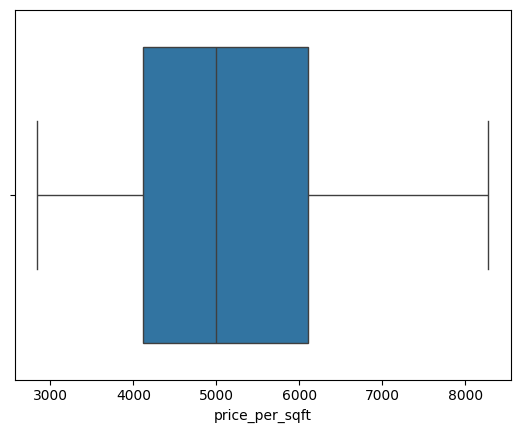

In [43]:
df=df[(df["price_per_sqft"]>=lower)&(df["price_per_sqft"]<=upper)]
sns.boxplot(x="price_per_sqft",data=df)

In [44]:
df.reset_index(inplace=True)

In [45]:
df

,index,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,0,Electronic City Phase II,2 BHK,1056.0,2,39.07,2,3699.810606
1,1,Chikka Tirupathi,4 Bedroom,2600.0,5,120.00,4,4615.384615
2,2,Uttarahalli,3 BHK,1440.0,2,62.00,3,4305.555556
3,3,Lingadheeranahalli,3 BHK,1521.0,3,95.00,3,6245.890861
4,4,Kothanur,2 BHK,1200.0,2,51.00,2,4250.000000
...,...,...,...,...,...,...,...,...
9429,13310,Rachenahalli,2 BHK,1050.0,2,52.71,2,5020.000000
9430,13312,Bellandur,2 BHK,1262.0,2,47.00,2,3724.247227
9431,13314,Green Glen Layout,3 BHK,1715.0,3,112.00,3,6530.612245
9432,13315,Whitefield,5 Bedroom,3453.0,4,231.00,5,6689.834926


In [46]:
df=df.drop(["index","size","price_per_sqft"],axis=1)
df

,location,total_sqft,bath,price,bhk
0,Electronic City Phase II,1056.0,2,39.07,2
1,Chikka Tirupathi,2600.0,5,120.00,4
2,Uttarahalli,1440.0,2,62.00,3
3,Lingadheeranahalli,1521.0,3,95.00,3
4,Kothanur,1200.0,2,51.00,2
...,...,...,...,...,...
9429,Rachenahalli,1050.0,2,52.71,2
9430,Bellandur,1262.0,2,47.00,2
9431,Green Glen Layout,1715.0,3,112.00,3
9432,Whitefield,3453.0,4,231.00,5


Model Training

In [77]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import  RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
import joblib


In [68]:
encoder = LabelEncoder()
df['encoded_loc'] = encoder.fit_transform(df['location'])
df

,location,total_sqft,bath,price,bhk,encoded_loc
0,Electronic City Phase II,1056.0,2,39.07,2,75
1,Chikka Tirupathi,2600.0,5,120.00,4,57
2,Uttarahalli,1440.0,2,62.00,3,216
3,Lingadheeranahalli,1521.0,3,95.00,3,154
4,Kothanur,1200.0,2,51.00,2,146
...,...,...,...,...,...,...
9429,Rachenahalli,1050.0,2,52.71,2,183
9430,Bellandur,1262.0,2,47.00,2,40
9431,Green Glen Layout,1715.0,3,112.00,3,83
9432,Whitefield,3453.0,4,231.00,5,224


In [79]:
joblib.dump(encoder, "../notebook/location_encoder.joblib")

['../notebook/location_encoder.joblib']

In [49]:
x = df.drop(["location","price"],axis=1)
y = df.price
x

,total_sqft,bath,bhk,encoded_loc
0,1056.0,2,2,75
1,2600.0,5,4,57
2,1440.0,2,3,216
3,1521.0,3,3,154
4,1200.0,2,2,146
...,...,...,...,...
9429,1050.0,2,2,183
9430,1262.0,2,2,40
9431,1715.0,3,3,83
9432,3453.0,4,5,224


In [50]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [51]:
model = RandomForestRegressor(random_state=42)

In [66]:
params = {
    "n_estimators":[100,150,200,250,300,350,400],
    "max_depth":[3,4,5,6,7,10,15]
}

In [67]:
grid = GridSearchCV(estimator=model,param_grid=params,cv=5)
grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [3, 4, 5, 6, 7, 10, 15],
                         'n_estimators': [100, 150, 200, 250, 300, 350, 400]})

In [69]:
print("Best Params: ",grid.best_params_)
print("Best Score: ",grid.best_score_)

Best Params:  {'max_depth': 10, 'n_estimators': 100}
Best Score:  0.8393957723414426


In [70]:
ypred = grid.predict(x_test)
ypred

array([ 82.43741504,  66.21476868,  52.70768144, ...,  35.77959951,
       115.71252544,  38.82032619])

In [71]:
print("Training Eff: ", grid.score(x_train,y_train))
print("Testing Eff: ", grid.score(x_test,y_test))

Training Eff:  0.92407542987713
Testing Eff:  0.8027254851920209


In [72]:
r2_score(y_test,ypred)

0.8027254851920209

In [73]:
mean_absolute_error(y_test,ypred)

14.3300998505237

In [74]:
mean_squared_error(y_test,ypred)

452.69904822294956

In [64]:
df.to_csv("../dataset/Cleaned_bangloreHousePrice_df.csv")

In [75]:
import joblib

with open("rf_model.joblib", 'wb') as file:
    joblib.dump(grid,file)

In [83]:
location = encoder.classes_
location

array(['1st Block Jayanagar', '1st Phase JP Nagar',
       '2nd Stage Nagarbhavi', '5th Block Hbr Layout',
       '5th Phase JP Nagar', '6th Phase JP Nagar', '7th Phase JP Nagar',
       '8th Phase JP Nagar', '9th Phase JP Nagar', 'AECS Layout',
       'Abbigere', 'Akshaya Nagar', 'Ambalipura', 'Ambedkar Nagar',
       'Amruthahalli', 'Anandapura', 'Ananth Nagar', 'Anekal',
       'Anjanapura', 'Ardendale', 'Arekere', 'Attibele', 'BTM 2nd Stage',
       'BTM Layout', 'Babusapalaya', 'Balagere', 'Banashankari',
       'Banashankari Stage II', 'Banashankari Stage III',
       'Banashankari Stage V', 'Banashankari Stage VI', 'Banaswadi',
       'Banjara Layout', 'Bannerghatta', 'Bannerghatta Road',
       'Basavangudi', 'Basaveshwara Nagar', 'Battarahalli', 'Begur',
       'Begur Road', 'Bellandur', 'Benson Town', 'Bharathi Nagar',
       'Bhoganhalli', 'Billekahalli', 'Binny Pete', 'Bisuvanahalli',
       'Bommanahalli', 'Bommasandra', 'Bommasandra Industrial Area',
       'Bommenahalli'